# MNIST-Fashion

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import itertools
import time
import os

# ==========================================
# 1. Real World Data Loading (Fashion MNIST)
# ==========================================

print("Fetching Fashion-MNIST from OpenML (this may take a moment)...")
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False, cache=True)
y = y.astype(int)
    

Fetching Fashion-MNIST from OpenML (this may take a moment)...


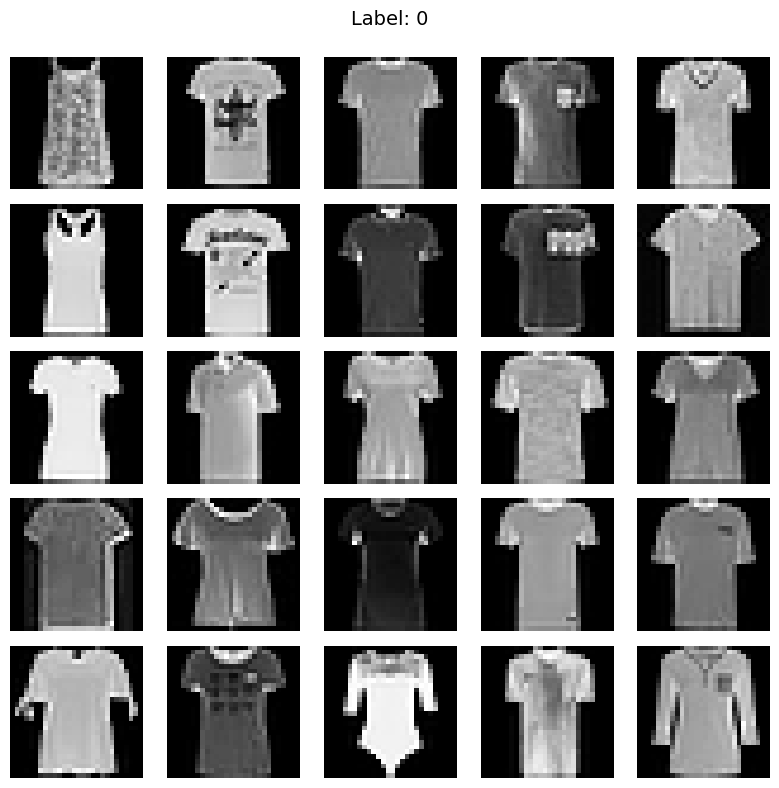

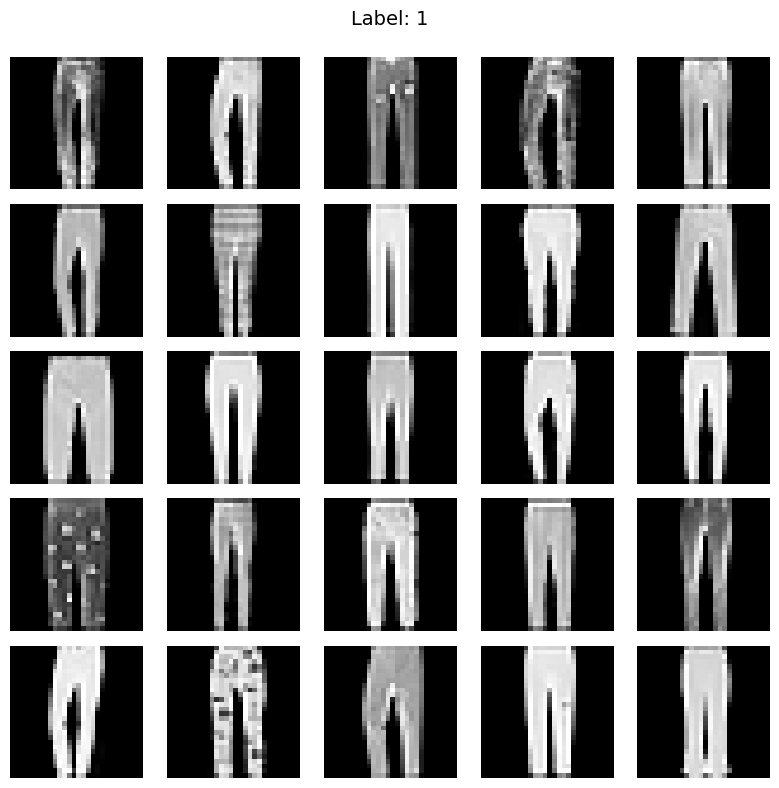

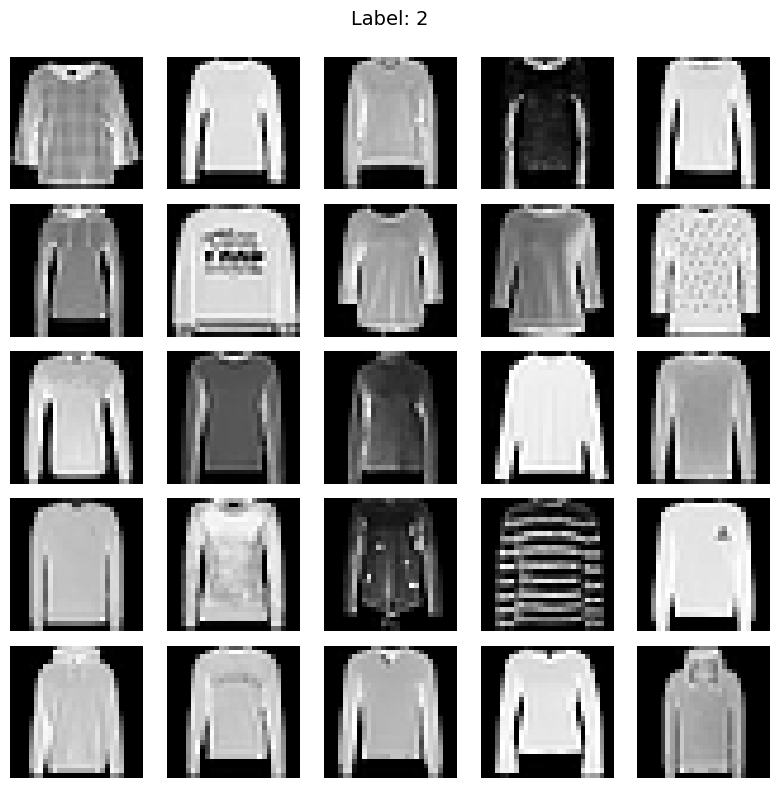

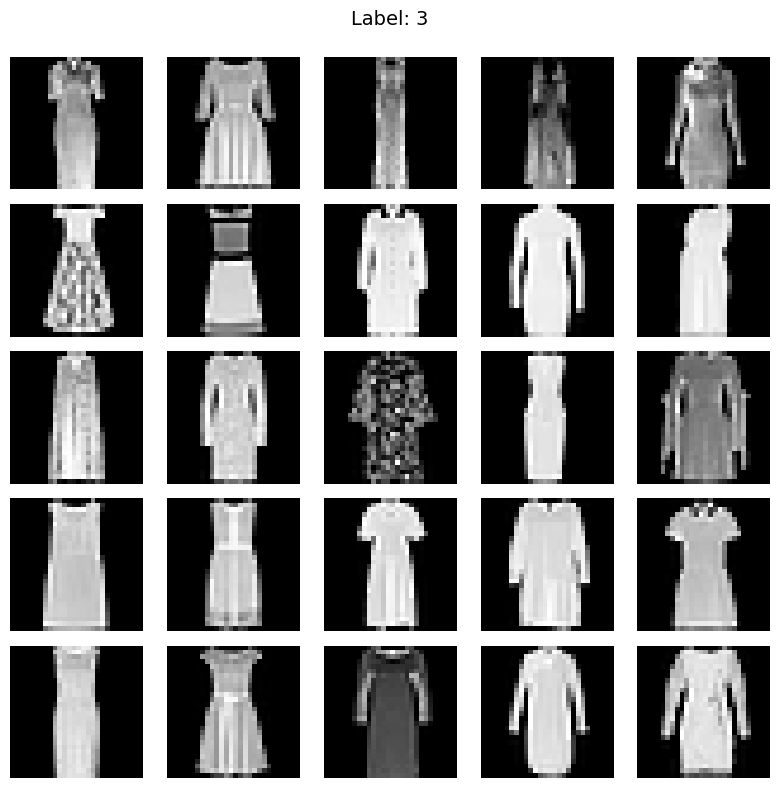

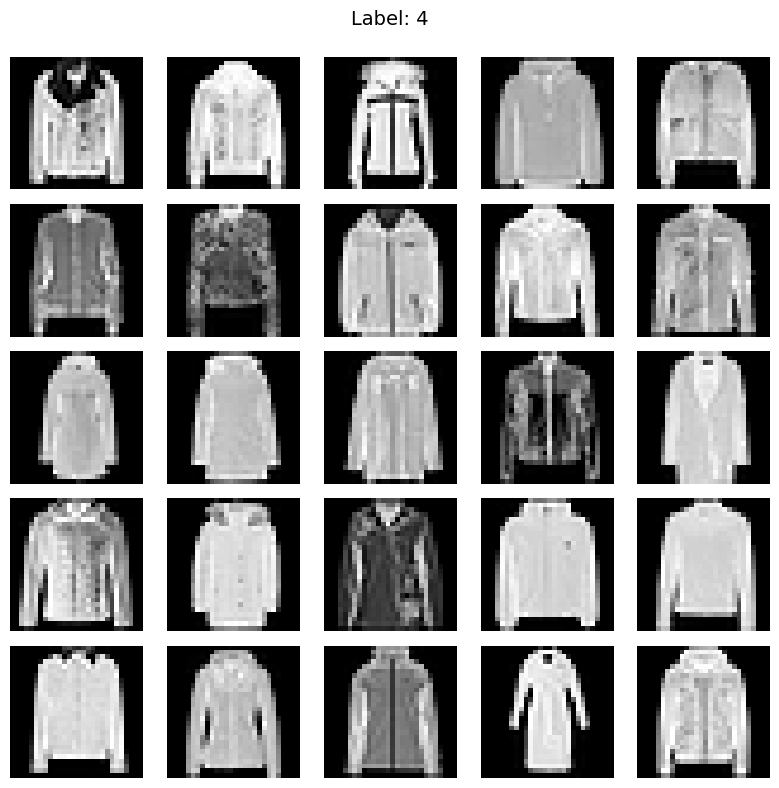

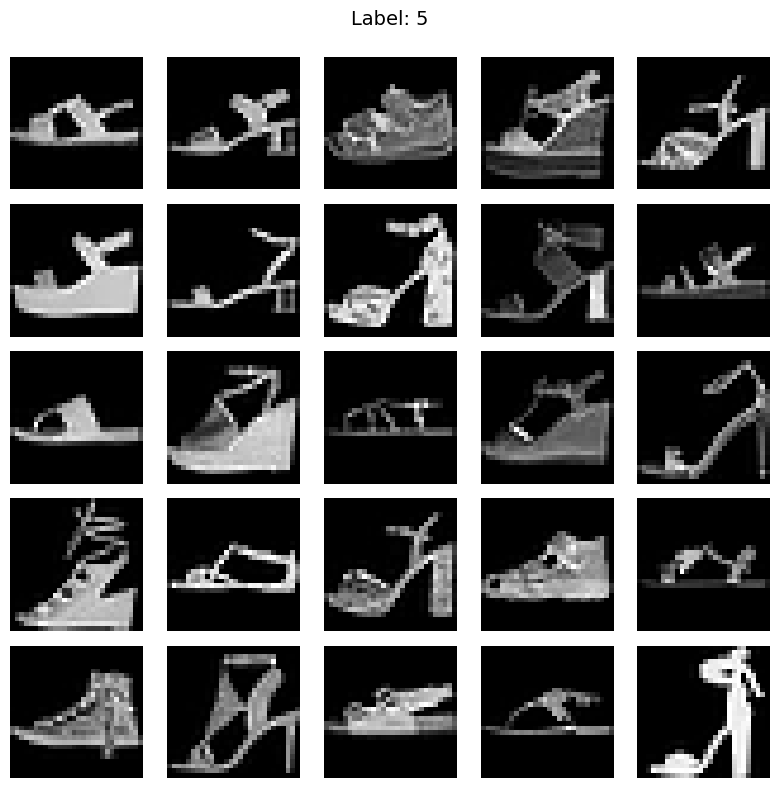

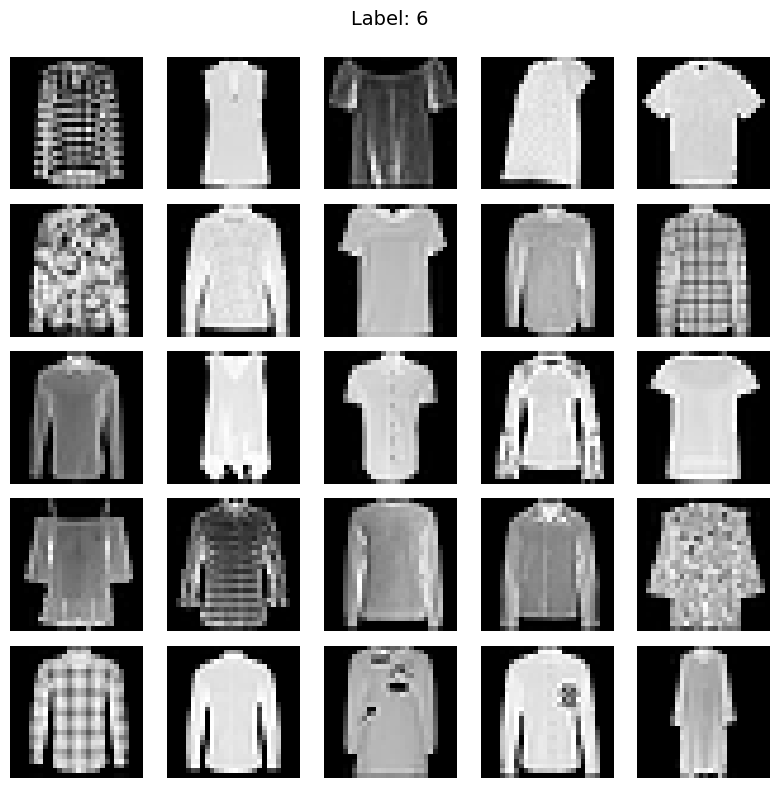

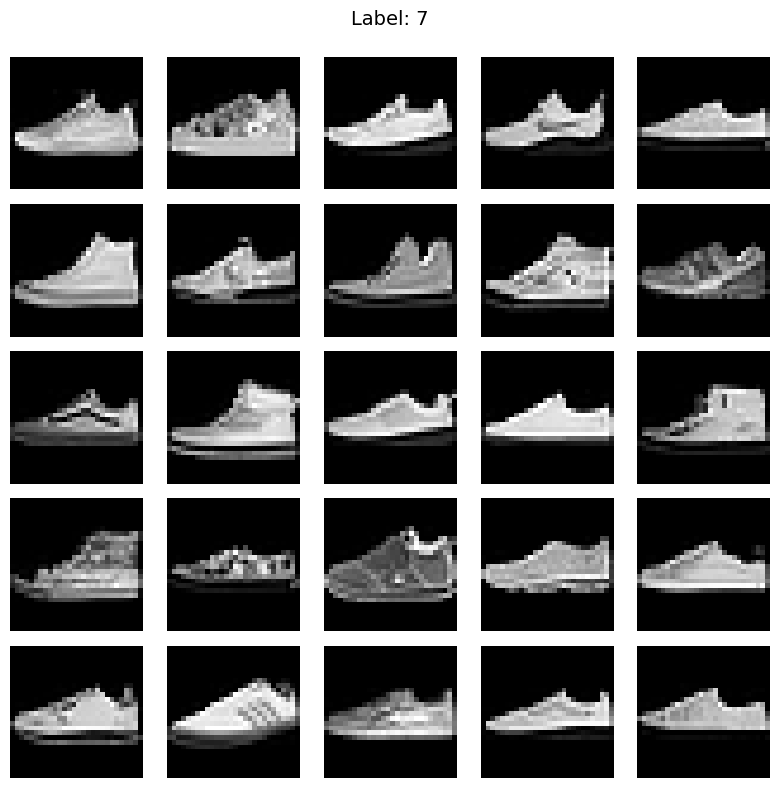

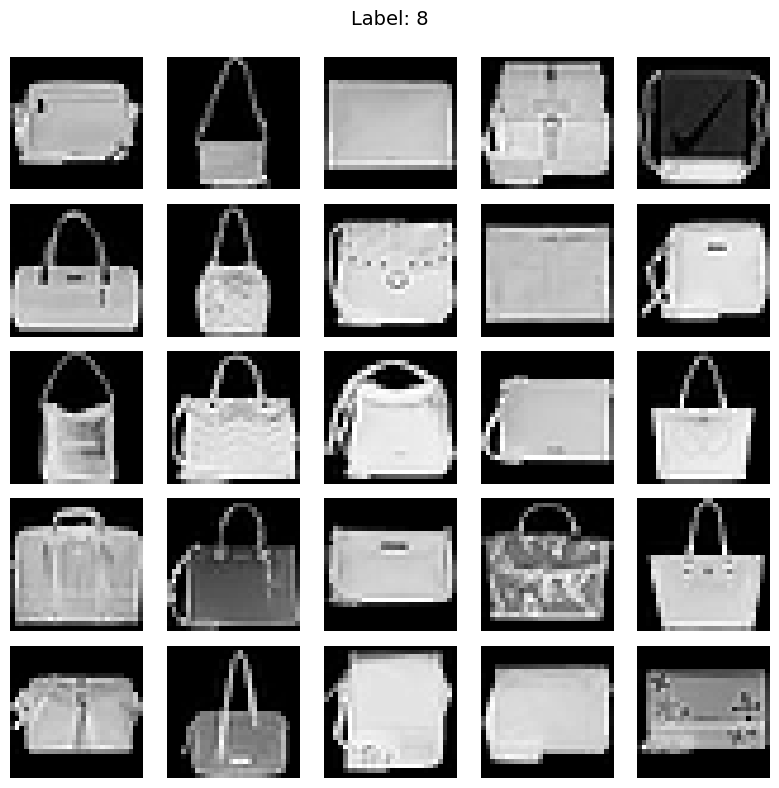

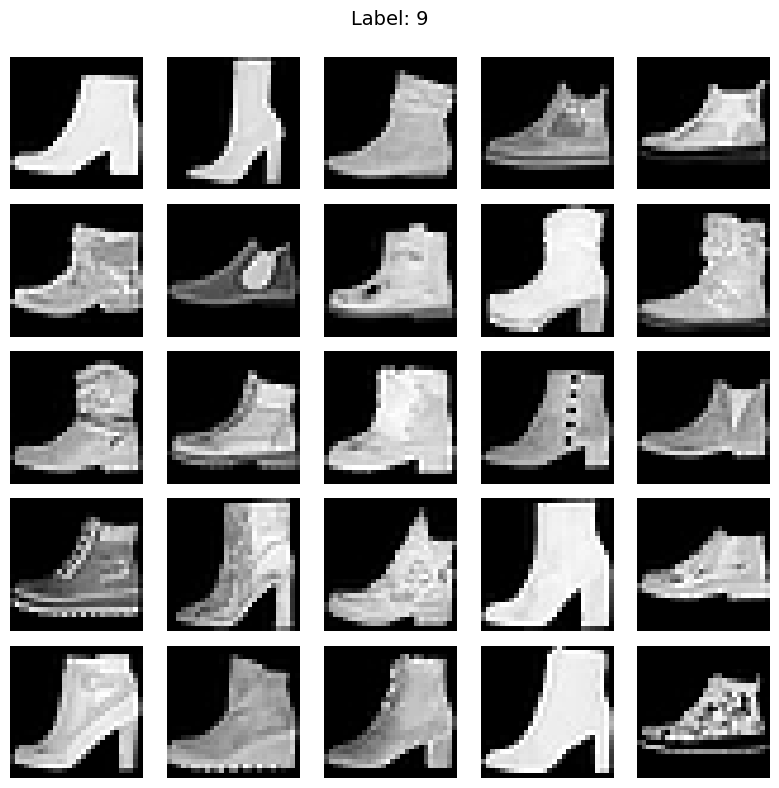

In [9]:
# Visualize 25 random images for each label
unique_labels = np.unique(y)

for label in unique_labels:
    # Get indices for this label
    label_indices = np.where(y == label)[0]
    
    # Select 25 random indices
    if len(label_indices) >= 25:
        indices = np.random.choice(label_indices, 25, replace=False)
    else:
        indices = label_indices
        
    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    fig.suptitle(f"Label: {label}", fontsize=14)
    
    for i, ax in enumerate(axes.flat):
        if i < len(indices):
            idx = indices[i]
            ax.imshow(X[idx].reshape(28, 28), cmap='gray')
            ax.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

In [ ]:
# PCA Projection of the entire dataset
print("Running PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit Label')
plt.title('PCA Projection of Fashion-MNIST')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Soybean

In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# 1. Load Data
print("Loading Soybean data...")
soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
X_df = soybean.data
y_fine_raw = soybean.target

# 2. Impute Missing Values (Still as Strings)
# 'most_frequent' fills '?' with the mode category
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X_df)

# 3. CRITICAL STEP: Encode Features to Numbers
# Converts strings like 'normal' -> 0, 'abnormal' -> 1
encoder = OrdinalEncoder()
X = encoder.fit_transform(X_imputed)

# 4. Map Hierarchy (Fine -> Coarse)
hierarchy_map = {
    # --- Parent: Leaf Spots ---
    'brown-spot': 'Leaf Spots',
    'alternaria-leaf-spot': 'Leaf Spots',
    'frog-eye-leaf-spot': 'Leaf Spots',
    'phyllosticta-leaf-spot': 'Leaf Spots',
    'downy-mildew': 'Leaf Spots',
    'powdery-mildew': 'Leaf Spots',
    
    # --- Parent: Root/Stem Rots ---
    'diaporthe-stem-canker': 'Root/Stem Rots',
    'charcoal-rot': 'Root/Stem Rots',
    'rhizoctonia-root-rot': 'Root/Stem Rots',
    'phytophthora-rot': 'Root/Stem Rots',
    'brown-stem-rot': 'Root/Stem Rots',
    'anthracnose': 'Root/Stem Rots',
    'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
    
    # --- Parent: Bacterial ---
    'bacterial-blight': 'Bacterial',
    'bacterial-pustule': 'Bacterial',
    'purple-seed-stain': 'Bacterial',
    
    # --- Parent: Environmental/Other ---
    '2-4-d-injury': 'Environmental',
    'herbicide-injury': 'Environmental',
    'cyst-nematode': 'Environmental'
}

# Convert labels
y_fine_strings = y_fine_raw.astype(str)
y_coarse_strings = np.array([hierarchy_map.get(label, 'Other') for label in y_fine_strings])

# Encode Labels to Integers
le_fine = LabelEncoder()
y_fine = le_fine.fit_transform(y_fine_strings)

le_coarse = LabelEncoder()
y_coarse = le_coarse.fit_transform(y_coarse_strings)

print("--- Data Ready ---")
print(f"Features (X): {X.shape} (Type: {X.dtype})")
print(f"Coarse Labels: {le_coarse.classes_}")

# 5. Variance Check
def check_variance(X, y_c, y_f, parent_idx):
    # Calculate Variance of the Parent Group
    parent_mask = (y_c == parent_idx)
    if np.sum(parent_mask) == 0: return 0, 0 # Safety check
    parent_var = np.var(X[parent_mask], axis=0).mean()
    
    # Calculate Variance of ONE Child Subclass
    child_labels = np.unique(y_f[parent_mask])
    child_mask = (y_f == child_labels[0]) # Pick the first subclass found
    child_var = np.var(X[child_mask], axis=0).mean()
    
    return parent_var, child_var

# Test on Index 0 (usually 'Bacterial' or 'Environmental')
for parent_idx in range(len(le_coarse.classes_)):
    p_var, c_var = check_variance(X, y_coarse, y_fine, parent_idx=parent_idx)

    print(f"\nVariance Check for Parent Class '{le_coarse.classes_[parent_idx]}':")
    print(f"Parent Variance: {p_var:.4f}")
    print(f"Child Variance:  {c_var:.4f}")

    if c_var < p_var:
        print(">> SUCCESS: Subclass is tighter (lower variance) than Parent.")
    else:
        print(">> NOTE: Variance condition not met for this specific class.")

Loading Soybean data...
--- Data Ready ---
Features (X): (683, 35) (Type: float64)
Coarse Labels: ['Bacterial' 'Environmental' 'Leaf Spots' 'Other' 'Root/Stem Rots']

Variance Check for Parent Class 'Bacterial':
Parent Variance: 0.4060
Child Variance:  0.2472
>> SUCCESS: Subclass is tighter (lower variance) than Parent.

Variance Check for Parent Class 'Environmental':
Parent Variance: 0.2582
Child Variance:  0.1669
>> SUCCESS: Subclass is tighter (lower variance) than Parent.

Variance Check for Parent Class 'Leaf Spots':
Parent Variance: 0.4181
Child Variance:  0.2689
>> SUCCESS: Subclass is tighter (lower variance) than Parent.

Variance Check for Parent Class 'Other':
Parent Variance: 0.2627
Child Variance:  0.2627
>> NOTE: Variance condition not met for this specific class.

Variance Check for Parent Class 'Root/Stem Rots':
Parent Variance: 0.5163
Child Variance:  0.3607
>> SUCCESS: Subclass is tighter (lower variance) than Parent.


## algo v4

Fetching Soybean data from OpenML...
Filtering 'Other' class... Dropped 91 samples.
Data Loaded: 592 samples, 99 Expanded Dimensions.
Parent Classes: 4 (['Bacterial' 'Environmental' 'Leaf Spots' 'Root/Stem Rots'])
Target Latent Dimension (C-1): 3
Running Grid Search (W shape: d x 3)...
10000/10000 | Best: 0.91
Best Params: {'alpha': 0.2, 'l1': 1.0, 'l2': 10.0, 'tau': 0.9}
Running Final Optimization...


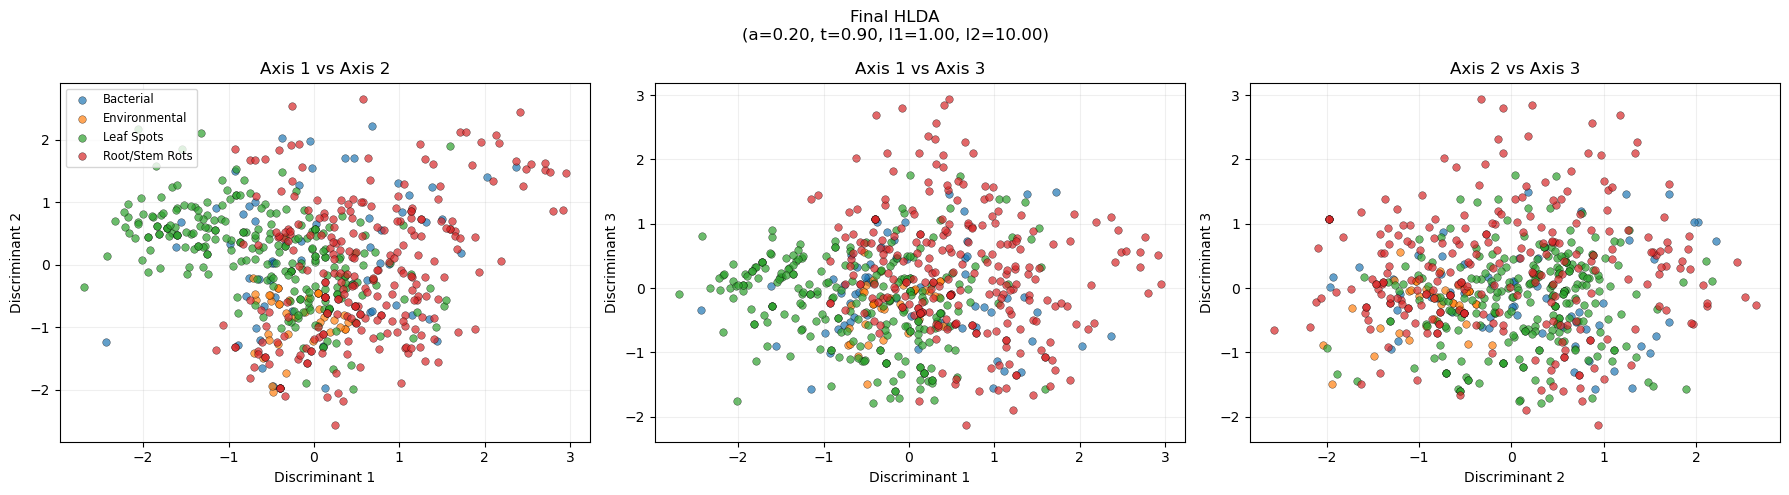


--- Topology Audit (Axis 1 vs 2) ---
Parent 'Bacterial': contains 3 subclasses
Parent 'Environmental': contains 3 subclasses
Parent 'Leaf Spots': contains 5 subclasses
Parent 'Root/Stem Rots': contains 7 subclasses


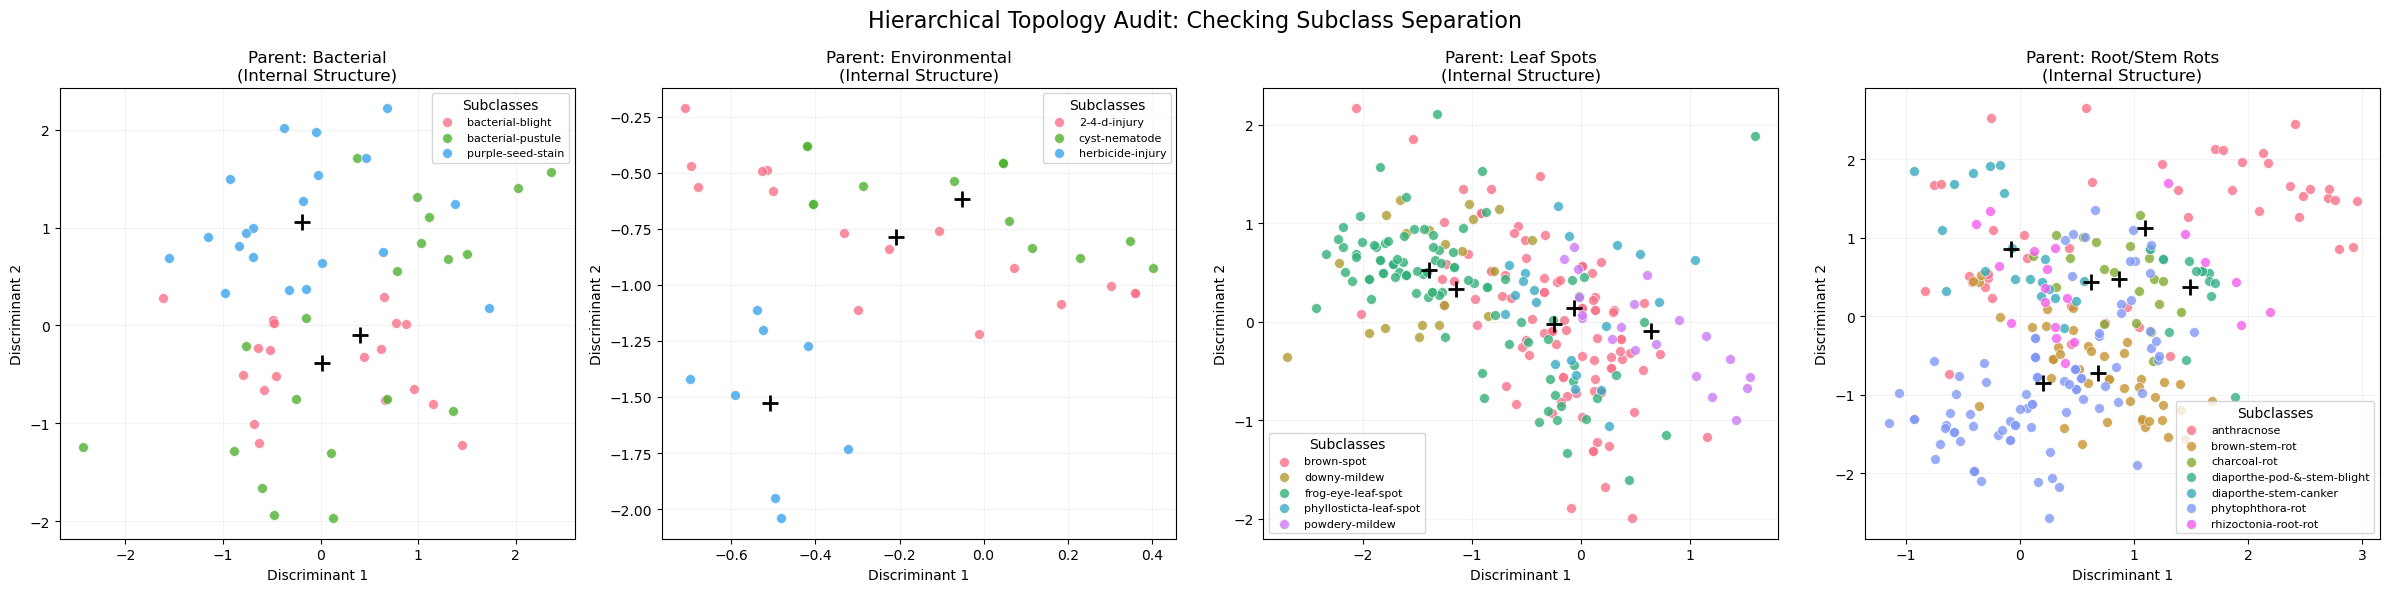

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns  # Added for better color palettes
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
import itertools
import os

# ==========================================
# 1. Real World Data Loading (Soybean Large)
# ==========================================
def get_soybean_hierarchy():
    print("Fetching Soybean data from OpenML...")
    soybean = fetch_openml(data_id=42, as_frame=True, parser='auto')
    X_df = soybean.data
    y_raw = soybean.target
    
    # 1. Handle Missing Values
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X_df)
    
    # 2. One-Hot Encoding (Crucial for Categorical Distance)
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = encoder.fit_transform(X_imputed)
    
    # 3. Hierarchy Mapping
    hierarchy_map = {
        'brown-spot': 'Leaf Spots', 'alternaria-leaf-spot': 'Leaf Spots',
        'frog-eye-leaf-spot': 'Leaf Spots', 'phyllosticta-leaf-spot': 'Leaf Spots',
        'downy-mildew': 'Leaf Spots', 'powdery-mildew': 'Leaf Spots',
        
        'diaporthe-stem-canker': 'Root/Stem Rots', 'charcoal-rot': 'Root/Stem Rots',
        'rhizoctonia-root-rot': 'Root/Stem Rots', 'phytophthora-rot': 'Root/Stem Rots',
        'brown-stem-rot': 'Root/Stem Rots', 'anthracnose': 'Root/Stem Rots',
        'diaporthe-pod-&-stem-blight': 'Root/Stem Rots',
        
        'bacterial-blight': 'Bacterial', 'bacterial-pustule': 'Bacterial',
        'purple-seed-stain': 'Bacterial',
        
        '2-4-d-injury': 'Environmental', 'herbicide-injury': 'Environmental',
        'cyst-nematode': 'Environmental'
    }
    
    y_fine_str = y_raw.astype(str)
    y_coarse_str = np.array([hierarchy_map.get(label, 'Other') for label in y_fine_str])
    
    # --- CRITICAL FIX: Filter out 'Other' Class ---
    valid_mask = y_coarse_str != 'Other'
    print(f"Filtering 'Other' class... Dropped {np.sum(~valid_mask)} samples.")
    
    X_encoded = X_encoded[valid_mask]
    y_fine_str = y_fine_str[valid_mask]
    y_coarse_str = y_coarse_str[valid_mask]
    
    # Encode Labels
    le_coarse = LabelEncoder()
    y_cls = le_coarse.fit_transform(y_coarse_str) 
    class_names = {i: name for i, name in enumerate(le_coarse.classes_)}
    
    # --- UPDATE: Return y_fine and its encoder for visualization ---
    le_fine = LabelEncoder()
    y_fine = le_fine.fit_transform(y_fine_str)
    
    # Cluster Tuples
    final_labels_cluster = []
    for i in range(len(y_cls)):
        final_labels_cluster.append((y_cls[i], y_fine[i]))
    
    # Standardize
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_encoded)
    
    print(f"Data Loaded: {X_norm.shape[0]} samples, {X_norm.shape[1]} Expanded Dimensions.")
    print(f"Parent Classes: {len(le_coarse.classes_)} ({le_coarse.classes_})")
    
    # Returns updated signature with y_fine and le_fine
    return X_norm, y_cls, y_fine, np.array(final_labels_cluster), class_names, le_fine, len(le_coarse.classes_)

# ==========================================
# 2. Matrices & Helper Functions
# ==========================================
def compute_matrices(data, labels_class, labels_cluster, dims):
    overall_mean = np.mean(data, axis=0)
    unique_classes = np.unique(labels_class)
    S_B = np.zeros((dims, dims)); S_WS = np.zeros((dims, dims)); S_BS = np.zeros((dims, dims))
    parent_means = {}; subclass_means = {}
    mu_tot = overall_mean
    
    for c in unique_classes:
        idx = np.where(labels_class == c)[0]
        X_c = data[idx, :]; N_c = X_c.shape[0]; mu_c = np.mean(X_c, axis=0)
        parent_means[c] = mu_c
        S_B += N_c * np.outer(mu_c - overall_mean, mu_c - overall_mean)
        
        current_cluster_labels = labels_cluster[idx]
        unique_subs = np.unique([lbl[1] for lbl in current_cluster_labels])
        
        subclass_means[c] = []
        for sub in unique_subs:
            mask = np.array([(lbl[0] == c and lbl[1] == sub) for lbl in labels_cluster])
            idx_sub = np.where(mask)[0]
            if len(idx_sub) == 0: continue
            
            X_cs = data[idx_sub, :]
            N_cs = X_cs.shape[0]; mu_cs = np.mean(X_cs, axis=0)
            subclass_means[c].append(mu_cs)
            
            diff = X_cs - mu_cs
            S_WS += diff.T @ diff
            S_BS += N_cs * np.outer(mu_cs - mu_c, mu_cs - mu_c)
            
    return S_B, S_WS, S_BS, parent_means, subclass_means, mu_tot

def grad_norm_wrt_W(W, diff_vec, eps=1e-8):
    proj = W.T @ diff_vec
    norm_val = np.linalg.norm(proj) + eps
    grad = np.outer(diff_vec, proj) / norm_val
    return grad, norm_val

# ==========================================
# 3. Optimization Logic (Dynamic K)
# ==========================================
def joint_gradient_ascent_v4(S_B, S_WS, S_BS, subclass_means, parent_means, mu_tot, 
                             n_components=2, reg=1e-4, num_iters=300, fix_hyperparams=None, verbose=True):
    dims = S_B.shape[0]
    np.random.seed(42) 
    W = np.random.randn(dims, n_components); W, _ = np.linalg.qr(W)
    
    # Defaults
    alpha = fix_hyperparams['alpha'] if fix_hyperparams else 0.5
    l1 = fix_hyperparams['l1'] if fix_hyperparams else 1.0 
    l2 = fix_hyperparams['l2'] if fix_hyperparams else 1.0 
    tau = fix_hyperparams['tau'] if fix_hyperparams else 0.5  
    
    step_W = 1e-5; step_hyp = 1e-4; eps_div = 1e-3     
    gamma_alpha = 5.0; decay_l = 0.01      
    
    history = []; hW = []
    
    for it in range(num_iters):
        S_mix = alpha * S_WS + (1 - alpha) * S_BS + reg * np.eye(dims)
        
        # S_R (Numerator)
        S_R_val = 0.0; grad_S_R = np.zeros_like(W)
        for c, sub_means in subclass_means.items():
            num_sub = len(sub_means)
            for i in range(num_sub):
                for j in range(i+1, num_sub):
                    diff = sub_means[i] - sub_means[j]
                    grad, n_val = grad_norm_wrt_W(W, diff, eps=eps_div)
                    inv_norm = 1.0 / (n_val + eps_div)
                    S_R_val += inv_norm
                    grad_S_R += -(inv_norm**2) * grad
                    
        # S_T (Denominator)
        S_T_val = 0.0; grad_S_T = np.zeros_like(W)
        for c, sub_means in subclass_means.items():
            for mu_cs in sub_means:
                diff_anchor = mu_cs - parent_means[c]
                g_anchor, n_anchor = grad_norm_wrt_W(W, diff_anchor, eps=eps_div)
                diff_global = mu_cs - mu_tot
                proj_global = W.T @ diff_global
                n_global_sq = np.dot(proj_global, proj_global)
                g_global_sq = 2 * np.outer(diff_global, proj_global)
                
                loss = n_anchor - tau * n_global_sq
                if loss > 0:
                    S_T_val += loss
                    grad_S_T += (g_anchor - tau * g_global_sq)

        tr_num = np.trace(W.T @ S_B @ W)
        tr_den = np.trace(W.T @ S_mix @ W)
        N = tr_num + l2 * S_R_val
        D = tr_den + l1 * S_T_val + eps_div 
        ratio = N / D
        
        grad_N_W = 2 * S_B @ W + l2 * grad_S_R
        grad_D_W = 2 * S_mix @ W + l1 * grad_S_T
        grad_J_W = (D * grad_N_W - N * grad_D_W) / (D**2)
        
        gnorm = np.linalg.norm(grad_J_W)
        if gnorm > 1.0: grad_J_W = grad_J_W / gnorm
        
        if gnorm > 1e4: 
            if verbose: print("Gradient explosion detected. Stopping.")
            break
        
        if not fix_hyperparams:
            dD_da = np.trace(W.T @ (S_WS - S_BS) @ W)
            grad_alpha = (-(N * dD_da) / (D**2)) - (2 * gamma_alpha * (alpha - 0.5))
            grad_l1 = (-(N * S_T_val) / (D**2)) - (2 * decay_l * l1)
            grad_l2 = (S_R_val / D) - (2 * decay_l * l2)
            l1 = max(l1 + step_hyp * grad_l1, 1e-4) 
            l2 = max(l2 + step_hyp * grad_l2, 1e-4)
            alpha = np.clip(alpha + step_hyp * grad_alpha, 0.1, 0.9) 
            
        W += step_W * grad_J_W; W, _ = np.linalg.qr(W)
        history.append(ratio)
        hW.append(gnorm)
        
        if verbose and it % 50 == 0:
            print(f"Iter {it}: Ratio={ratio:.4f}, a={alpha:.2f}, l1={l1:.2f}, l2={l2:.2f}", end='\r')
            
    return W, alpha, l1, l2, tau, history, hW

# ==========================================
# 4. Grid Search
# ==========================================
def run_grid_search(S_B, S_WS, S_BS, sub_means, par_means, mu_tot, reg, n_comp):
    print(f"Running Grid Search (W shape: d x {n_comp})...")
    alphas = np.linspace(0.2, 0.8, 10) 
    l1s = np.linspace(1.0, 50, 10) 
    l2s = np.linspace(1.0, 10, 10) 
    taus = np.linspace(0.1, 0.9, 10) 
    
    grid = {'alpha': alphas, 'l1': l1s, 'l2': l2s, 'tau': taus}
    keys, values = zip(*grid.items())
    
    best_obj = -np.inf; best_params = None; best_W = None
    total = np.prod([len(v) for v in values])
    
    count = 0
    for bundle in itertools.product(*values):
        params = dict(zip(keys, bundle))
        W_curr, _, _, _, _, hist, _ = joint_gradient_ascent_v4(
            S_B, S_WS, S_BS, sub_means, par_means, mu_tot, 
            n_components=n_comp, reg=reg, num_iters=30, 
            fix_hyperparams=params, verbose=False 
        )
        if hist and hist[-1] > best_obj:
            best_obj = hist[-1]
            best_params = params
            best_W = W_curr.copy()
        count += 1
        if count % 50 == 0: print(f"{count}/{total} | Best: {best_obj:.2f}", end='\r')
            
    print(f"\nBest Params: {best_params}")
    return best_params, best_W, best_obj

# ==========================================
# 5. Visualizations
# ==========================================
def run_visualizations(W, alpha, l1, l2, tau, data, y_cls, class_names, dims, title_prefix):
    proj = data @ W
    n_components = W.shape[1]
    axis_pairs = list(itertools.combinations(range(n_components), 2))
    n_plots = len(axis_pairs)
    
    if n_plots == 0: 
        print("Only 1 component. Cannot plot 2D scatter.")
        return

    fig, axs = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1: axs = [axs]
    
    u_parents = np.unique(y_cls)
    cmap = plt.colormaps['tab10']
    
    for plot_idx, (ax1, ax2) in enumerate(axis_pairs):
        ax = axs[plot_idx]
        for i, c in enumerate(u_parents):
            idx = np.where(y_cls == c)[0]
            label_name = class_names.get(c, f"Class {c}")
            ax.scatter(proj[idx, ax1], proj[idx, ax2], label=label_name,
                       color=cmap(i), alpha=0.7, s=30, edgecolor='k', linewidth=0.3)
            
        ax.set_title(f"Axis {ax1+1} vs Axis {ax2+1}")
        ax.set_xlabel(f"Discriminant {ax1+1}")
        ax.set_ylabel(f"Discriminant {ax2+1}")
        if plot_idx == 0: ax.legend(loc='upper left', fontsize='small')
        ax.grid(True, alpha=0.2)
        
    plt.suptitle(f"{title_prefix}\n(a={alpha:.2f}, t={tau:.2f}, l1={l1:.2f}, l2={l2:.2f})")
    plt.tight_layout()
    plt.show()

# ==========================================
# 6. Subclass Topology Audit (NEW)
# ==========================================
def visualize_subclass_topology(W, data, y_cls, y_fine, parent_names, le_fine, title_prefix):
    """
    Visualizes the internal topology of each Parent Class by plotting its Subclasses.
    """
    # 1. Project Data into Latent Space
    proj = data @ W
    d1, d2 = 0, 1 # View first two discriminants
    
    unique_parents = np.unique(y_cls)
    n_parents = len(unique_parents)
    
    fig, axs = plt.subplots(1, n_parents, figsize=(6 * n_parents, 6))
    if n_parents == 1: axs = [axs]
    
    print(f"\n--- Topology Audit (Axis {d1+1} vs {d2+1}) ---")
    
    for i, p_idx in enumerate(unique_parents):
        ax = axs[i]
        p_name = parent_names.get(p_idx, f"Parent {p_idx}")
        
        # 1. Get all samples for this Parent
        parent_mask = (y_cls == p_idx)
        X_parent = proj[parent_mask]
        y_sub_local = y_fine[parent_mask]
        
        # 2. Identify Subclasses
        unique_subs = np.unique(y_sub_local)
        
        # Color palette
        palette = sns.color_palette("husl", len(unique_subs))
        
        print(f"Parent '{p_name}': contains {len(unique_subs)} subclasses")
        
        for j, s_idx in enumerate(unique_subs):
            sub_mask = (y_sub_local == s_idx)
            X_sub = X_parent[sub_mask]
            
            # Lookup real name
            s_name = le_fine.inverse_transform([s_idx])[0]
            
            # Scatter Plot
            ax.scatter(X_sub[:, d1], X_sub[:, d2], label=s_name, 
                       color=palette[j], alpha=0.8, s=50, edgecolor='white', linewidth=0.5)
            
            # Draw Centroid
            mu = np.mean(X_sub, axis=0)
            ax.plot(mu[d1], mu[d2], 'k+', markersize=12, markeredgewidth=2)
            
        ax.set_title(f"Parent: {p_name}\n(Internal Structure)")
        ax.set_xlabel(f"Discriminant {d1+1}")
        ax.set_ylabel(f"Discriminant {d2+1}")
        ax.legend(title="Subclasses", fontsize='8', loc='best')
        ax.grid(True, alpha=0.15)
        
    plt.suptitle(f"{title_prefix}: Checking Subclass Separation", fontsize=16)
    plt.tight_layout()
    plt.show()

# ==========================================
# Main
# ==========================================
if __name__ == "__main__":
    reg = 1e-4
    
    # 1. Load Data (Updated to return y_fine and le_fine)
    data, y_cls, y_fine, y_clst, class_names, le_fine, n_classes = get_soybean_hierarchy()
    
    # 2. Determine Latent Dimension (C - 1)
    latent_dim = n_classes - 1 
    print(f"Target Latent Dimension (C-1): {latent_dim}")
    
    # 3. Compute Matrices
    Sb, Sws, Sbs, pm, sm, mt = compute_matrices(data, y_cls, y_clst, data.shape[1])
    
    # 4. Grid Search
    best_p, best_W_grid, best_obj = run_grid_search(Sb, Sws, Sbs, sm, pm, mt, reg, latent_dim)
    
    # 5. Full Gradient Ascent
    print("Running Final Optimization...")
    W_final, a, l1, l2, t, h, hW = joint_gradient_ascent_v4(
            Sb, Sws, Sbs, sm, pm, mt, 
            n_components=latent_dim,
            reg=reg, num_iters=2000, fix_hyperparams=best_p,
            verbose=True
        )
    
    # 6. Show "Choose 2" Projections (Parent Separation)
    run_visualizations(W_final, a, l1, l2, t, data, y_cls, class_names, data.shape[1], "Final HLDA")

    # 7. Show Subclass Topology (Detailed Audit)
    visualize_subclass_topology(W_final, data, y_cls, y_fine, class_names, le_fine, "Hierarchical Topology Audit")